## 3. <a id='toc3_'></a>[Problem 3: Barycentric interpolation](#toc0_)

**Problem:** We have a set of random points in the unit square,

$$
\mathcal{X} = \{(x_1,x_2)\,|\,x_1\sim\mathcal{U}(0,1),x_2\sim\mathcal{U}(0,1)\}.
$$

For these points, we know the value of some function $f(x_1,x_2)$,

$$
\mathcal{F} = \{f(x_1,x_2) \,|\, (x_1,x_2) \in \mathcal{X}\}.
$$

Now we want to approximate the value $f(y_1,y_2)$ for some  $y=(y_1,y_2)$, where $y_1\sim\mathcal{U}(0,1)$ and $y_2\sim\mathcal{U}(0,1)$.

**Building block I**

For an arbitrary triangle $ABC$ and a point $y$, define the so-called barycentric coordinates as:

$$
\begin{align*}
  r^{ABC}_1 &= \frac{(B_2-C_2)(y_1-C_1) + (C_1-B_1)(y_2-C_2)}{(B_2-C_2)(A_1-C_1) + (C_1-B_1)(A_2-C_2)} \\
  r^{ABC}_2 &= \frac{(C_2-A_2)(y_1-C_1) + (A_1-C_1)(y_2-C_2)}{(B_2-C_2)(A_1-C_1) + (C_1-B_1)(A_2-C_2)} \\
  r^{ABC}_3 &= 1 - r_1 - r_2.
\end{align*}
$$

If $r^{ABC}_1 \in [0,1]$, $r^{ABC}_2 \in [0,1]$, and $r^{ABC}_3 \in [0,1]$, then the point is inside the triangle.

We always have $y = r^{ABC}_1 A + r^{ABC}_2 B + r^{ABC}_3 C$.

**Building block II**

Define the following points:

$$
\begin{align*}
A&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}>y_{1}\text{ and }x_{2}>y_{2}\\
B&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}>y_{1}\text{ and }x_{2}<y_{2}\\
C&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}<y_{1}\text{ and }x_{2}<y_{2}\\
D&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}<y_{1}\text{ and }x_{2}>y_{2}.
\end{align*}
$$

**Algorithm:**

1. Compute $A$, $B$, $C$, and $D$. If not possible return `NaN`.
1. If $y$ is inside the triangle $ABC$ return $r^{ABC}_1 f(A) + r^{ABC}_2 f(B) + r^{ABC}_3 f(C)$.
1. If $y$ is inside the triangle $CDA$ return $r^{CDA}_1 f(C) + r^{CDA}_2 f(D) + r^{CDA}_3 f(A)$.
1. Return `NaN`.



**Sample:**

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# Import class
from barycentric_interpolation import barycentric_interpolation

# Define barycentric interpolater as reference to class
interpolater = barycentric_interpolation()

# Generate random numbers
rng = np.random.default_rng(2024)

X = rng.uniform(size=(50,2))
y = rng.uniform(size=(2,))


**Questions 1:** Find $A$, $B$, $C$ and $D$. Illustrate these together with $X$, $y$ and the triangles $ABC$ and $CDA$.

In [123]:
A,B,C,D = interpolater.find_ABCD(X,y)

------------------------------------------------------------------------------------------------------------------------
Finding coordinates for A,B,C and D
A,B,C and D coordinates have been succesfully found:
A: (0.26,0.44)
B: (0.21,0.27)
C: (0.10,0.28)
D: (0.21,0.44)
------------------------------------------------------------------------------------------------------------------------


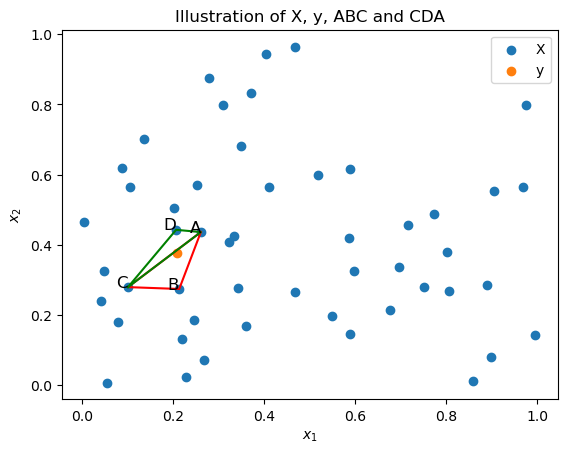

In [124]:
# Determine x1 and x2 values for the triangles
ABC_x1 = [A[0], B[0], C[0], A[0]]
ABC_x2 = [A[1], B[1], C[1], A[1]]

CDA_x1 = [C[0], D[0], A[0], C[0]]
CDA_x2 = [C[1], D[1], A[1], C[1]]

# Plot x1 and x2 values for both the set X and the soon-to-be interpolated set y as scatter plots
X_plot = plt.scatter(X[:,0],X[:,1])
y_plot = plt.scatter(y[0],y[1])

# Plot the triangles using the values
ABC = plt.plot(ABC_x1,ABC_x2,color='red')
CDA = plt.plot(CDA_x1,CDA_x2,color='green')

# Add labels to triangle vertices
plt.text(A[0], A[1], 'A', fontsize=12, ha='right')
plt.text(B[0], B[1], 'B', fontsize=12, ha='right')
plt.text(C[0], C[1], 'C', fontsize=12, ha='right')
plt.text(D[0], D[1], 'D', fontsize=12, ha='right')

# Add title, labels and legend
plt.title('Illustration of X, y, ABC and CDA')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend((X_plot,y_plot),("X", "y"))

**Question 2:** Compute the barycentric coordinates of the point $y$ with respect to the triangles $ABC$ and $CDA$. Which triangle is $y$ located inside?

In [125]:
if interpolater.compute_barycentric_coordinates(A,B,C,y)[1]:
    print(f'y is in triangle ABC')

------------------------------------------------------------------------------------------------------------------------
Finding barycentric coordinates for the triangle
Barycentric coordinates have been estimated:
r1ABC = 0.63
r2ABC = 0.07
r3ABC = 0.30
y is in the triangle
------------------------------------------------------------------------------------------------------------------------
y is in triangle ABC


Now consider the function:
$$
f(x_1,x_2) = x_1 \cdot x_2
$$

In [126]:
f = lambda x: x[0]*x[1]
F = np.array([f(x) for x in X])

**Question 3:** Compute the approximation of $f(y)$ using the full algorithm. Compare with the true value.

In [127]:
interpolater.barycentric_algorithm(X,y,f)

------------------------------------------------------------------------------------------------------------------------
Barycentric interpolation result for y = (0.21,0.38) ---> 0.08405     compared to f(y)=f(0.21,0.38) = 0.07896
Barycentric interpolation approximates f(y)=f(0.21,0.38) with 98.94% accuracy
------------------------------------------------------------------------------------------------------------------------


0.08405201731052576

**Question 4:** Repeat question 3 for all points in the set $Y$.

In [128]:
Y = [(0.2,0.2),(0.8,0.2),(0.8,0.8),(0.8,0.2),(0.5,0.5)]

In [131]:
for y in Y:
    interpolater.barycentric_algorithm(X,y,f)

------------------------------------------------------------------------------------------------------------------------
Barycentric interpolation result for y = (0.20,0.20) ---> 0.04033     compared to f(y)=f(0.20,0.20) = 0.04000
Barycentric interpolation approximates f(y)=f(0.20,0.20) with 98.99% accuracy
------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------
Barycentric interpolation result for y = (0.80,0.20) ---> 0.15874     compared to f(y)=f(0.80,0.20) = 0.16000
Barycentric interpolation approximates f(y)=f(0.80,0.20) with 99.01% accuracy
------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------
A, B, C or D cant b

In [130]:
assert
def eval(x1,x2,best,best_coordinates,y):
    # Function that takes two new coordinates, the old best (lowest) objective function value and the old coordinates that constituted it
    # If the two new coordinates constitute a lower objective function value, then the function should return these and the new (best) lowest objective function value
    # If not, the old (and yet best) two coordinates and their corresponding objective function value should be returned

    # Compute objective function for two new coordinates
    obj = np.sqrt((x1-y[0])**2+(x2-y[1])**2)

    # Evaluate whether new objective function is lower than the best so far
    if obj < best:

        # Update best objective function and coordinates with the new
        best_new = obj
        best_xpair = (x1,x2)
    
    # If it is not the lowest so far, let the new best objective function be the old best and let the coordinates remain the same
    else:
        best_new = best
        best_xpair = best_coordinates

    # Return (yet) best x coordinates and objective function value
    return best_xpair, best_new

def find_ABCD(X,y):

    obj_best = np.ones(4)*np.inf
    best_coordinates = np.zeros((4,2))

    # Loop over x1 and x2 values pairwise
    for x1,x2 in X:

        # Evalute whether the given conditions are fulfilled
        # The first element in the list is for A, second for B, third for C and fourth for D
        bool = [x1 > y[0] and x2 > y[1], x1 > y[0] and x2 < y[1], x1 < y[0] and x2 < y[1], x1 < y[0] and x2 > y[1]]

        # Loop over the list of booleans
        for i,b in enumerate(bool):

            # If the conditions are fulfilled, then proceed to evaluate and replace objective function value and coordinates
            if b == True:
                best_coordinates[i,:], obj_best[i] = eval(x1,x2,obj_best[i],best_coordinates[i,:],y)
        
            # If not, it remains the same as the best coordinates and lowest (best) objective function value is stored in the global scope
    
    print(f'Issues with determining ABCD: {(best_coordinates == 0).any()}')

    if (best_coordinates == 0).any() == True:
        print('Problem with determining coordinates for ABCD. Coordinates for ABCD will be set to NaN')
        best_coordinates = np.ones((4,2))*np.NaN

    # Convert array of lists with best coordinates to a list of tuples with the coordinate pairs
    ABCD_coordinates = [tuple(i) for i in best_coordinates]

    return ABCD_coordinates

def compute_barycentric_coordinates(A,B,C,y,print_statement=False):

    # Use inspect package to get the input variable names
    sig = inspect.signature(compute_barycentric_coordinates)
    triangle_vertices = list(sig.parameters.keys())

    # Compute the denominator since it is the same for both fractions for r1ABC and r2ABC
    denom = (B[1]-C[1])*(A[0]-C[0])+(C[0]-B[0])*(A[1]-C[1])
    r1ABC = ((B[1]-C[1])*(y[0]-C[0])+(C[0]-B[0])*(y[1]-C[1]))/(denom)
    r2ABC = ((C[1]-A[1])*(y[0]-C[0])+(A[0]-C[0])*(y[1]-C[1]))/(denom)
    r3ABC = 1 - r1ABC - r2ABC

    # Store barycentric coordinates in a list of coordinates
    list_of_r = [r1ABC,r2ABC,r3ABC]

    # Loop through barycentric coordinates and append the boolean for whether the barycentric coordinat is between 0 and 1
    list_of_r_bool = []
    for i in list_of_r:
        list_of_r_bool.append(0 < i < 1)

    # Access whether all the booleans are true

    is_in_triangle = all(list_of_r_bool)

    if print_statement == True:
        if is_in_triangle == True:
            print(f'y is in the triangle {triangle_vertices[0]}{triangle_vertices[1]}{triangle_vertices[2]}')

        else:
            print(f'y is NOT in the triangle {triangle_vertices[0]}{triangle_vertices[1]}{triangle_vertices[2]}')

    return list_of_r,is_in_triangle

def barycentric_algorithm(X,y,function):
    # 1. Use set X to find the A,B,C and D coordinates and values to be unpacked in respectively coordinates_ABCD and function_value_ABCD
    coordinates_ABCD = find_ABCD(X,y)
    A,B,C,D = coordinates_ABCD

    if np.isnan(coordinates_ABCD[0][0]):
        print(f'Interpolation fails')
        result_interpolation = np.NaN

    ABC_barycentric = compute_barycentric_coordinates(A,B,C,y,print_statement=True)
    CDA_barycentric = compute_barycentric_coordinates(C,D,A,y,print_statement=True)

    # 2. Check if y is in ABC
    if ABC_barycentric[1] == True:
        
        # Unpack barycentric coordinates
        list_of_r = ABC_barycentric[0]

        # Compute interpolated function value for y
        result_interpolation = list_of_r[0]*function(A)+list_of_r[1]*function(B)+list_of_r[2]*function(C)

    # 3. Check if y is in CDA
    if CDA_barycentric[1] == True:

        # Unpack barycentric coordinates
        list_of_r = CDA_barycentric[0]

        # Compute interpolated function value for y
        result_interpolation = list_of_r[2]*function(C)+list_of_r[3]*function(D)+list_of_r[0]*function(A)

    return result_interpolation

SyntaxError: invalid syntax (1614174417.py, line 1)